In [ ]:
!pip install -q xgboost

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [ ]:
def find_file(filename):
    candidates = [
        filename,
        f"/content/{filename}",
        f"/mnt/data/{filename}"
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"{filename} not found. Upload it to Colab.")

train = pd.read_csv(find_file("dataset_Repeat_training.csv"))
test = pd.read_csv(find_file("dataset_Repeat_testing.csv"))

TARGET = "Transported"
ID = "PassengerId"

print("train:", train.shape, "| test:", test.shape)
display(train.head())

train: (5798, 14) | test: (2895, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,2010_01,Earth,True,G/324/P,PSO J318.5-22,33.0,False,0.0,0.0,0.0,0.0,NaN,Candyn Gregordy,True
1,3117_01,Earth,False,F/646/P,TRAPPIST-1e,32.0,False,0.0,0.0,47.0,857.0,23.0,NaN,False
2,5848_01,Earth,False,E/377/S,NaN,28.0,False,229.0,761.0,0.0,0.0,6.0,Eriana Benney,True
3,7785_01,Earth,False,G/1261/S,TRAPPIST-1e,13.0,False,406.0,0.0,52.0,0.0,387.0,Luise Bucklandez,False
4,8375_01,Earth,False,NaN,PSO J318.5-22,15.0,False,64.0,0.0,0.0,0.0,640.0,Carlen Valezaley,True


In [ ]:
print("TRAIN INFO")
train.info()

print("\nTEST INFO")
test.info()

print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test :", test.duplicated().sum())
print("Duplicate PassengerIds in train:", train[ID].duplicated().sum())
print("Duplicate PassengerIds in test :", test[ID].duplicated().sum())

display(train.describe(include="all").T)

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5798 entries, 0 to 5797
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   5798 non-null   object 
 1   HomePlanet    5660 non-null   object 
 2   CryoSleep     5657 non-null   object 
 3   Cabin         5663 non-null   object 
 4   Destination   5676 non-null   object 
 5   Age           5678 non-null   float64
 6   VIP           5660 non-null   object 
 7   RoomService   5679 non-null   float64
 8   FoodCourt     5682 non-null   float64
 9   ShoppingMall  5668 non-null   float64
 10  Spa           5675 non-null   float64
 11  VRDeck        5665 non-null   float64
 12  Name          5655 non-null   object 
 13  Transported   5798 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 594.7+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 13 columns):
 #   Column  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,5798,5798,1142_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HomePlanet,5660,3,Earth,3079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CryoSleep,5657,2,False,3633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cabin,5663,4659,C/21/P,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,5676,3,TRAPPIST-1e,3949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5678.0,NaN,NaN,NaN,28.877598,14.561429,0.0,19.0,27.0,38.0,78.0
VIP,5660,2,False,5523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RoomService,5679.0,NaN,NaN,NaN,218.186124,647.070964,0.0,0.0,0.0,42.0,9920.0
FoodCourt,5682.0,NaN,NaN,NaN,455.892819,1606.591863,0.0,0.0,0.0,82.0,29813.0
ShoppingMall,5668.0,NaN,NaN,NaN,169.183663,616.175949,0.0,0.0,0.0,25.0,23492.0


,Count,Percent
Transported,,
True,2923,50.41
False,2875,49.59


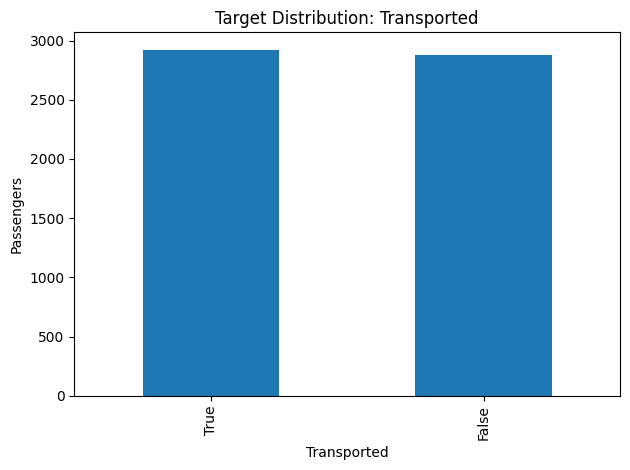

In [ ]:
target_summary = pd.DataFrame({
    "Count": train[TARGET].value_counts(),
    "Percent": (train[TARGET].value_counts(normalize=True) * 100).round(2)
})
display(target_summary)

train[TARGET].value_counts().plot(kind="bar")
plt.title("Target Distribution: Transported")
plt.xlabel("Transported")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

,Missing_Count,Missing_Percent
Name,143,2.47
CryoSleep,141,2.43
VIP,138,2.38
HomePlanet,138,2.38
Cabin,135,2.33
VRDeck,133,2.29
ShoppingMall,130,2.24
Spa,123,2.12
Destination,122,2.10
Age,120,2.07


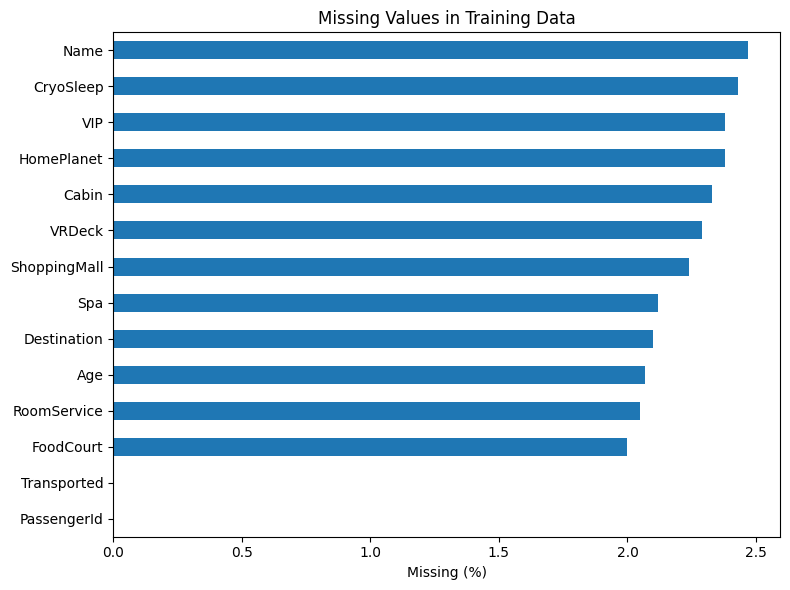

In [ ]:
missing_summary = pd.DataFrame({
    "Missing_Count": train.isna().sum(),
    "Missing_Percent": (train.isna().mean() * 100).round(2)
}).sort_values("Missing_Percent", ascending=False)

display(missing_summary)

missing_summary["Missing_Percent"].sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Missing Values in Training Data")
plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()

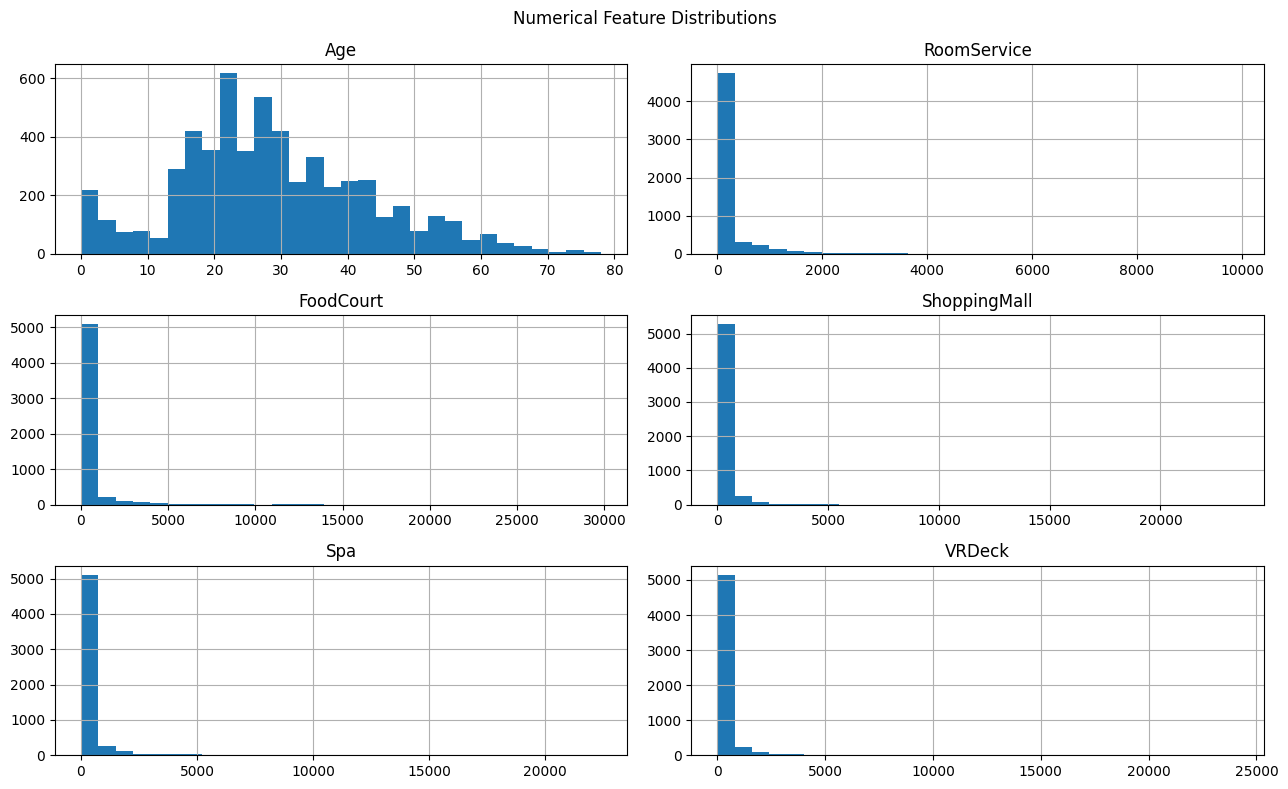

,count,Transport_Rate
NoSpend,,
False,3360,0.297024
True,2438,0.789582


In [ ]:
numeric_cols_original = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

train[numeric_cols_original].hist(figsize=(13,8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
eda_spend = train.copy()
eda_spend["TotalSpend"] = eda_spend[spend_cols].sum(axis=1, min_count=1)
eda_spend["NoSpend"] = (eda_spend[spend_cols].fillna(0).sum(axis=1) == 0)

display(
    eda_spend.groupby("NoSpend")[TARGET]
    .agg(["count", "mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

In [ ]:
for col in ["HomePlanet", "CryoSleep", "Destination", "VIP"]:
    print(f"\nTransport rate by {col}")
    display(
        train.groupby(col, dropna=False)[TARGET]
        .agg(["count","mean"])
        .rename(columns={"mean":"Transport_Rate"})
        .sort_values("Transport_Rate", ascending=False)
    )


Transport rate by HomePlanet


,count,Transport_Rate
HomePlanet,,
Europa,1439,0.653926
Mars,1142,0.550788
NaN,138,0.492754
Earth,3079,0.417343



Transport rate by CryoSleep


,count,Transport_Rate
CryoSleep,,
True,2024,0.819664
NaN,141,0.517730
False,3633,0.327828



Transport rate by Destination


,count,Transport_Rate
Destination,,
55 Cancri e,1206,0.601990
PSO J318.5-22,521,0.508637
NaN,122,0.475410
TRAPPIST-1e,3949,0.474551



Transport rate by VIP


,count,Transport_Rate
VIP,,
NaN,138,0.514493
False,5523,0.507333
True,137,0.364964


In [ ]:
temp = train.copy()

# Cabin components
cabin = (
    temp["Cabin"]
    .fillna("Unknown/Unknown/Unknown")
    .astype(str)
    .str.split("/", expand=True)
)
temp["CabinDeck"] = cabin[0]
temp["CabinSide"] = cabin[2]

print("Cabin Deck:")
display(
    temp.groupby("CabinDeck")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
    .sort_values("Transport_Rate", ascending=False)
)

print("Cabin Side:")
display(
    temp.groupby("CabinSide")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

# Passenger group
temp["GroupId"] = temp[ID].astype(str).str.split("_").str[0]
group_counts = temp["GroupId"].value_counts()
temp["GroupSize"] = temp["GroupId"].map(group_counts)
temp["TravelingSolo"] = temp["GroupSize"].eq(1)

print("Traveling Solo:")
display(
    temp.groupby("TravelingSolo")[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)

Cabin Deck:


,count,Transport_Rate
CabinDeck,,
B,529,0.737240
C,500,0.674000
Unknown,135,0.540741
G,1694,0.509445
A,163,0.466258
D,323,0.448916
F,1873,0.438868
E,578,0.373702
T,3,0.333333


Cabin Side:


,count,Transport_Rate
CabinSide,,
P,2845,0.450615
S,2818,0.556423
Unknown,135,0.540741


Traveling Solo:


,count,Transport_Rate
TravelingSolo,,
False,2133,0.563526
True,3665,0.469577


,count,Transport_Rate
AgeGroup,,
Child,543,0.694291
Teen,498,0.556225
YoungAdult,1537,0.461288
Adult,1934,0.474664
MiddleAge,1014,0.506903
Senior,152,0.467105


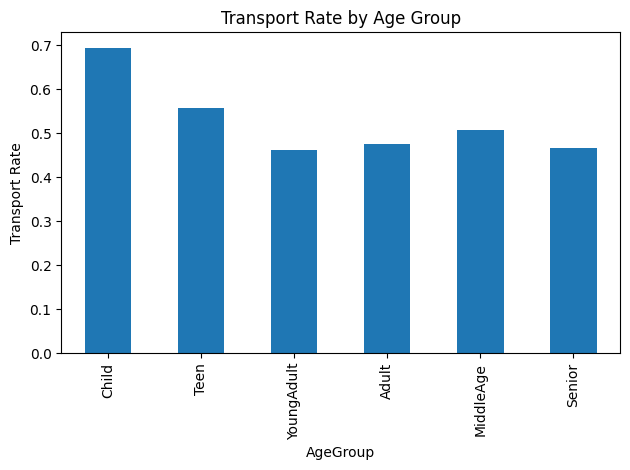

In [ ]:
age_temp = train.copy()
age_temp["AgeGroup"] = pd.cut(
    age_temp["Age"],
    bins=[-np.inf, 12, 17, 25, 40, 60, np.inf],
    labels=["Child","Teen","YoungAdult","Adult","MiddleAge","Senior"]
)

age_result = (
    age_temp.groupby("AgeGroup", observed=False)[TARGET]
    .agg(["count","mean"])
    .rename(columns={"mean":"Transport_Rate"})
)
display(age_result)

age_result["Transport_Rate"].plot(kind="bar")
plt.title("Transport Rate by Age Group")
plt.ylabel("Transport Rate")
plt.tight_layout()
plt.show()

In [ ]:
all_predictors = pd.concat(
    [train.drop(columns=TARGET), test],
    ignore_index=True
)

all_group_ids = all_predictors[ID].astype(str).str.split("_").str[0]
GROUP_COUNTS = all_group_ids.value_counts()

all_surnames = (
    all_predictors["Name"]
    .fillna("")
    .astype(str)
    .str.rsplit(n=1)
    .str[-1]
)
SURNAME_COUNTS = all_surnames[all_surnames != ""].value_counts()

def engineer_features(df):
    x = df.copy()

    # PassengerId -> group information
    pid = x[ID].astype(str)
    x["GroupId"] = pid.str.split("_").str[0]
    x["GroupMemberNo"] = pd.to_numeric(
        pid.str.split("_").str[1], errors="coerce"
    )
    x["GroupSize"] = x["GroupId"].map(GROUP_COUNTS)
    x["TravelingSolo"] = (x["GroupSize"] == 1).astype(int)

    # Cabin -> deck / number / side
    cabin = (
        x["Cabin"]
        .fillna("Unknown/Unknown/Unknown")
        .astype(str)
        .str.split("/", expand=True)
    )
    x["CabinDeck"] = cabin[0].replace("Unknown", np.nan)
    x["CabinNum"] = pd.to_numeric(
        cabin[1].replace("Unknown", np.nan), errors="coerce"
    )
    x["CabinSide"] = cabin[2].replace("Unknown", np.nan)

    # Spending
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    x["TotalSpend"] = x[spend_cols].sum(axis=1, min_count=1)
    x["NoSpend"] = (x[spend_cols].fillna(0).sum(axis=1) == 0).astype(int)
    x["LuxurySpend"] = x[["Spa","VRDeck"]].sum(axis=1, min_count=1)
    x["EssentialSpend"] = x[["RoomService","FoodCourt","ShoppingMall"]].sum(axis=1, min_count=1)

    for col in spend_cols + ["TotalSpend","LuxurySpend","EssentialSpend"]:
        x[f"log_{col}"] = np.log1p(x[col].clip(lower=0))

    # Name -> surname / family-size proxy
    x["Surname"] = (
        x["Name"].fillna("").astype(str)
        .str.rsplit(n=1).str[-1]
        .replace("", np.nan)
    )
    x["FamilySize"] = x["Surname"].map(SURNAME_COUNTS)

    # Age bands
    x["AgeGroup"] = pd.cut(
        x["Age"],
        bins=[-np.inf, 12, 17, 25, 40, 60, np.inf],
        labels=["Child","Teen","YoungAdult","Adult","MiddleAge","Senior"]
    )

    return x.drop(
        columns=[ID, "Cabin", "Name", "GroupId", "Surname"]
    )

X = engineer_features(train.drop(columns=TARGET))
y = train[TARGET].astype(int)
X_test = engineer_features(test)

print("Engineered X:", X.shape)
display(X.head())

Engineered X: (5798, 30)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,log_RoomService,log_FoodCourt,log_ShoppingMall,log_Spa,log_VRDeck,log_TotalSpend,log_LuxurySpend,log_EssentialSpend,FamilySize,AgeGroup
0,Earth,True,PSO J318.5-22,33.0,False,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,4.0,Adult
1,Earth,False,TRAPPIST-1e,32.0,False,0.0,0.0,47.0,857.0,23.0,...,0.000000,0.000000,3.871201,6.754604,3.178054,6.833032,6.781058,3.871201,NaN,Adult
2,Earth,False,NaN,28.0,False,229.0,761.0,0.0,0.0,6.0,...,5.438079,6.635947,0.000000,0.000000,1.945910,6.904751,1.945910,6.898715,7.0,Adult
3,Earth,False,TRAPPIST-1e,13.0,False,406.0,0.0,52.0,0.0,387.0,...,6.008813,0.000000,3.970292,0.000000,5.961005,6.740519,5.961005,6.129050,5.0,Teen
4,Earth,False,PSO J318.5-22,15.0,False,64.0,0.0,0.0,0.0,640.0,...,4.174387,0.000000,0.000000,0.000000,6.463029,6.558198,6.463029,4.174387,7.0,Teen


In [ ]:
categorical_cols = X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

numerical_cols = [c for c in X.columns if c not in categorical_cols]

def make_preprocessor(scale_numeric=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("num", Pipeline(num_steps), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (4638, 30)
Validation: (1160, 30)


In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    "SVM": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", SVC(kernel="rbf"))
    ]),

    "Random Forest": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

print("Candidate models:")
for name in models:
    print("-", name)

Candidate models:
- Logistic Regression
- SVM
- Random Forest
- HistGradientBoosting
- XGBoost


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rows = []

for name, model in models.items():
    print("Cross-validating:", name)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy":"accuracy",
            "f1":"f1",
            "roc_auc":"roc_auc"
        },
        n_jobs=-1
    )

    rows.append({
        "Model": name,
        "CV_Accuracy": scores["test_accuracy"].mean(),
        "CV_Accuracy_SD": scores["test_accuracy"].std(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values(
    "CV_Accuracy", ascending=False
)

display(cv_results.round(4))

Cross-validating: Logistic Regression
Cross-validating: SVM
Cross-validating: Random Forest
Cross-validating: HistGradientBoosting
Cross-validating: XGBoost


,Model,CV_Accuracy,CV_Accuracy_SD,CV_F1,CV_ROC_AUC
4,XGBoost,0.8038,0.0120,0.8062,0.8963
3,HistGradientBoosting,0.8006,0.0100,0.8012,0.8934
1,SVM,0.8004,0.0124,0.8082,0.8766
0,Logistic Regression,0.7963,0.0144,0.8030,0.8791
2,Random Forest,0.7909,0.0126,0.7906,0.8800


In [ ]:
holdout_rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val).astype(int)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_val)[:, 1]
    else:
        score = model.decision_function(X_val)

    holdout_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC_AUC": roc_auc_score(y_val, score)
    })
    fitted_models[name] = model

holdout_results = pd.DataFrame(holdout_rows).sort_values(
    ["Accuracy","ROC_AUC"],
    ascending=False
)

display(holdout_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,XGBoost,0.8172,0.8083,0.8359,0.8218,0.9091
3,HistGradientBoosting,0.8078,0.8037,0.8188,0.8112,0.9076
2,Random Forest,0.8069,0.8150,0.7983,0.8066,0.8875
1,SVM,0.8043,0.7788,0.8547,0.8150,0.8796
0,Logistic Regression,0.8034,0.7793,0.8513,0.8137,0.8796



Logistic Regression
                 precision    recall  f1-score   support

Not Transported       0.83      0.75      0.79       575
    Transported       0.78      0.85      0.81       585

       accuracy                           0.80      1160
      macro avg       0.81      0.80      0.80      1160
   weighted avg       0.81      0.80      0.80      1160



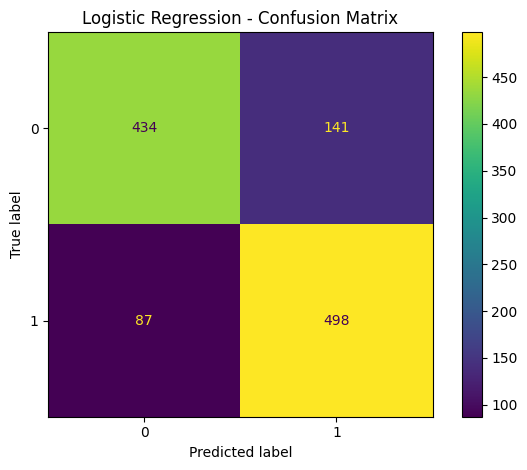

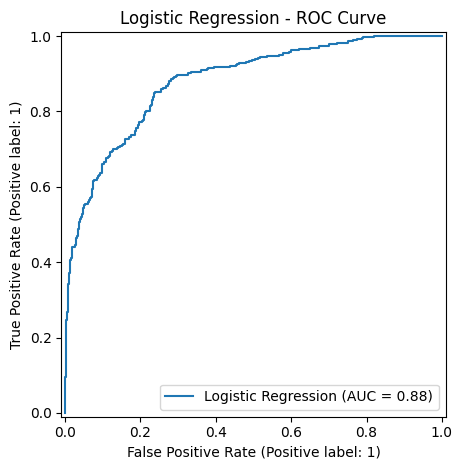


SVM
                 precision    recall  f1-score   support

Not Transported       0.84      0.75      0.79       575
    Transported       0.78      0.85      0.81       585

       accuracy                           0.80      1160
      macro avg       0.81      0.80      0.80      1160
   weighted avg       0.81      0.80      0.80      1160



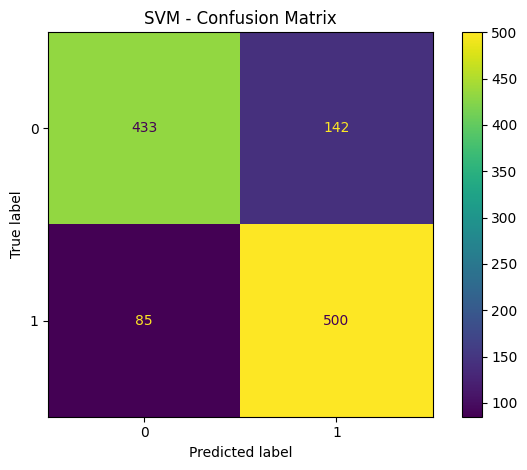

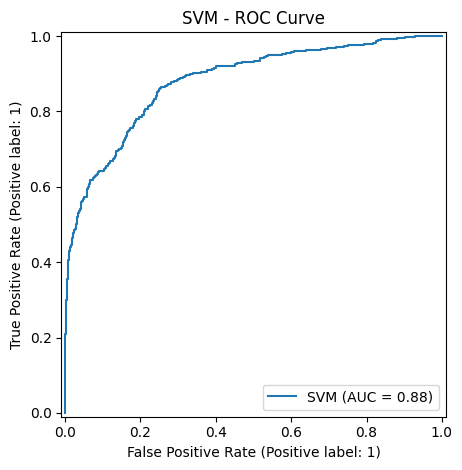


Random Forest
                 precision    recall  f1-score   support

Not Transported       0.80      0.82      0.81       575
    Transported       0.82      0.80      0.81       585

       accuracy                           0.81      1160
      macro avg       0.81      0.81      0.81      1160
   weighted avg       0.81      0.81      0.81      1160



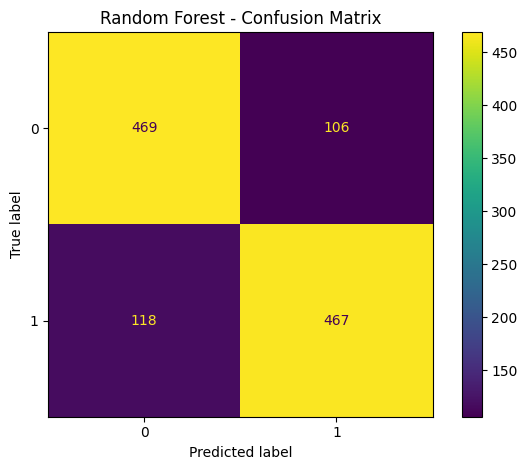

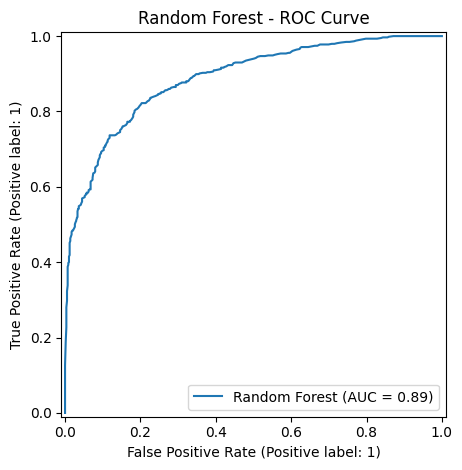


HistGradientBoosting
                 precision    recall  f1-score   support

Not Transported       0.81      0.80      0.80       575
    Transported       0.80      0.82      0.81       585

       accuracy                           0.81      1160
      macro avg       0.81      0.81      0.81      1160
   weighted avg       0.81      0.81      0.81      1160



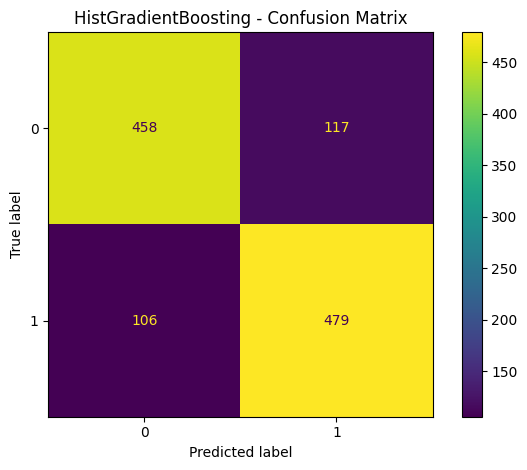

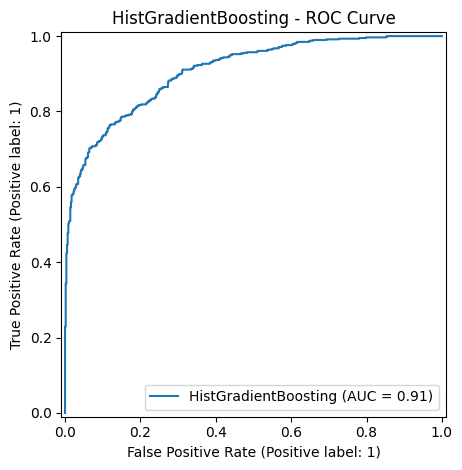


XGBoost
                 precision    recall  f1-score   support

Not Transported       0.83      0.80      0.81       575
    Transported       0.81      0.84      0.82       585

       accuracy                           0.82      1160
      macro avg       0.82      0.82      0.82      1160
   weighted avg       0.82      0.82      0.82      1160



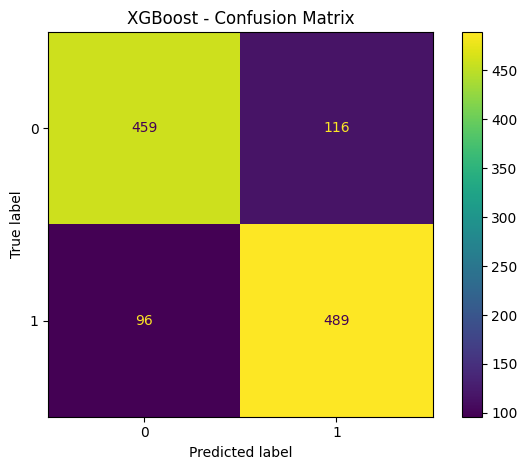

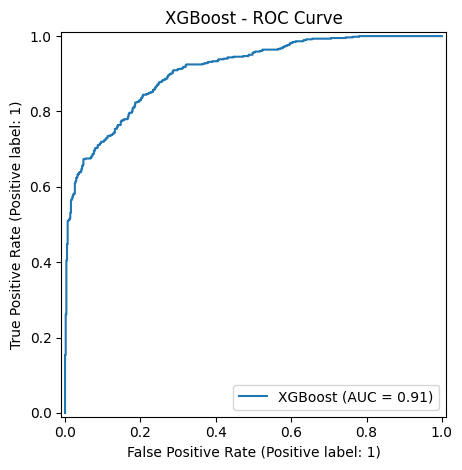

In [ ]:
for name, model in fitted_models.items():
    pred = model.predict(X_val).astype(int)

    print("\n" + "="*70)
    print(name)
    print("="*70)

    print(classification_report(
        y_val,
        pred,
        target_names=["Not Transported","Transported"]
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        pred,
        display_labels=["0","1"]
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_val)[:, 1]
    else:
        score = model.decision_function(X_val)

    RocCurveDisplay.from_predictions(
        y_val,
        score,
        name=name
    )
    plt.title(f"{name} - ROC Curve")
    plt.tight_layout()
    plt.show()

In [ ]:
xgb_pipeline = Pipeline([
    ("prep", make_preprocessor(False)),
    ("model", XGBClassifier(
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_grid = {
    "model__n_estimators": [250, 350, 450, 600],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_grid,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost CV accuracy:", round(xgb_search.best_score_, 4))
print("Best XGBoost params:", xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_val).astype(int)
xgb_prob = best_xgb.predict_proba(X_val)[:,1]

print("Validation Accuracy:", round(accuracy_score(y_val, xgb_pred), 4))
print("Validation F1:", round(f1_score(y_val, xgb_pred), 4))
print("Validation ROC-AUC:", round(roc_auc_score(y_val, xgb_prob), 4))

Best XGBoost CV accuracy: 0.8057
Best XGBoost params: {'model__subsample': 1.0, 'model__n_estimators': 350, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Validation Accuracy: 0.8086
Validation F1: 0.8134
Validation ROC-AUC: 0.9085


In [ ]:
# Keep strong tuned/configured versions for later ensemble and final ranking.
tuned_models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", LogisticRegression(
            C=3,
            penalty="l1",
            solver="liblinear",
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),

    "SVM": Pipeline([
        ("prep", make_preprocessor(True)),
        ("model", SVC(
            C=3,
            gamma=0.01,
            kernel="rbf",
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=18,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("prep", make_preprocessor(False)),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=1,
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": best_xgb
}

rows = []
fitted_tuned_models = {}

for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val).astype(int)

    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_val)[:,1]
    else:
        score = model.decision_function(X_val)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC_AUC": roc_auc_score(y_val, score)
    })
    fitted_tuned_models[name] = model

tuned_results = pd.DataFrame(rows).sort_values(
    ["Accuracy","ROC_AUC"],
    ascending=False
)

display(tuned_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,HistGradientBoosting,0.8164,0.8153,0.8222,0.8187,0.9091
4,XGBoost,0.8086,0.8000,0.8274,0.8134,0.9085
2,Random Forest,0.8043,0.8013,0.8137,0.8075,0.8913
0,Logistic Regression,0.8034,0.7793,0.8513,0.8137,0.8798
1,SVM,0.8000,0.7754,0.8496,0.8108,0.8830


In [ ]:
# ============================================================
#  WEIGHTED ENSEMBLE + FINAL MODEL RANKING
# ============================================================

# Models used in the ensemble
ensemble_names = [
    "HistGradientBoosting",
    "XGBoost",
    "Random Forest",
    "Logistic Regression"
]

# Weights based on validation performance
ensemble_weights = [
    0.40,   # HistGradientBoosting
    0.40,   # XGBoost
    0.10,   # Random Forest
    0.10    # Logistic Regression
]

# Get validation probabilities from the fitted tuned models
ensemble_probs = []

for name in ensemble_names:
    probs = fitted_tuned_models[name].predict_proba(X_val)[:, 1]
    ensemble_probs.append(probs)

# Weighted probability
weighted_prob = sum(
    weight * prob
    for weight, prob in zip(ensemble_weights, ensemble_probs)
)

# Convert probabilities to 0/1 predictions
weighted_pred = (weighted_prob >= 0.5).astype(int)

# Evaluate ensemble
ensemble_result = pd.DataFrame([{
    "Model": "Weighted Ensemble",
    "Accuracy": accuracy_score(y_val, weighted_pred),
    "Precision": precision_score(y_val, weighted_pred),
    "Recall": recall_score(y_val, weighted_pred),
    "F1": f1_score(y_val, weighted_pred),
    "ROC_AUC": roc_auc_score(y_val, weighted_prob)
}])

print("WEIGHTED ENSEMBLE PERFORMANCE")
display(ensemble_result.round(4))



# ============================================================

# IMPORTANT:
# Use ONLY the final tuned/configured model results here.
# Do NOT combine holdout_results again.

all_results = pd.concat(
    [
        tuned_results,
        ensemble_result
    ],
    ignore_index=True
)

# Guarantee that each model appears only once
all_results = (
    all_results
    .sort_values(
        ["Accuracy", "ROC_AUC", "F1"],
        ascending=False
    )
    .drop_duplicates(
        subset="Model",
        keep="first"
    )
    .reset_index(drop=True)
)

# Rank all six approaches
all_results.insert(
    0,
    "Rank",
    range(1, len(all_results) + 1)
)

print("FINAL SIX MODEL RANKING")
display(all_results.round(4))


# ============================================================
# SELECT TOP FIVE
# ============================================================

top5 = all_results.head(5).copy()

top5["Submission_File"] = [
    f"order_{i}.csv"
    for i in range(1, 6)
]

print("TOP FIVE MODELS FOR FINAL SUBMISSION")
display(top5.round(4))

WEIGHTED ENSEMBLE PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Weighted Ensemble,0.8991,0.8926,0.9094,0.9009,0.9744


FINAL SIX MODEL RANKING


,Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,Weighted Ensemble,0.8991,0.8926,0.9094,0.9009,0.9744
1,2,HistGradientBoosting,0.8164,0.8153,0.8222,0.8187,0.9091
2,3,XGBoost,0.8086,0.8000,0.8274,0.8134,0.9085
3,4,Random Forest,0.8043,0.8013,0.8137,0.8075,0.8913
4,5,Logistic Regression,0.8034,0.7793,0.8513,0.8137,0.8798
5,6,SVM,0.8000,0.7754,0.8496,0.8108,0.8830


TOP FIVE MODELS FOR FINAL SUBMISSION


,Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Submission_File
0,1,Weighted Ensemble,0.8991,0.8926,0.9094,0.9009,0.9744,order_1.csv
1,2,HistGradientBoosting,0.8164,0.8153,0.8222,0.8187,0.9091,order_2.csv
2,3,XGBoost,0.8086,0.8000,0.8274,0.8134,0.9085,order_3.csv
3,4,Random Forest,0.8043,0.8013,0.8137,0.8075,0.8913,order_4.csv
4,5,Logistic Regression,0.8034,0.7793,0.8513,0.8137,0.8798,order_5.csv


Training final: Logistic Regression
Training final: SVM
Training final: Random Forest
Training final: HistGradientBoosting
Training final: XGBoost
order_1.csv <- Weighted Ensemble
order_2.csv <- HistGradientBoosting
order_3.csv <- XGBoost
order_4.csv <- Random Forest
order_5.csv <- Logistic Regression

FINAL SUBMISSION FILES


,Rank,Model,File,Rows,Predicted_0,Predicted_1
0,1,Weighted Ensemble,order_1.csv,2895,1414,1481
1,2,HistGradientBoosting,order_2.csv,2895,1439,1456
2,3,XGBoost,order_3.csv,2895,1434,1461
3,4,Random Forest,order_4.csv,2895,1464,1431
4,5,Logistic Regression,order_5.csv,2895,1363,1532
